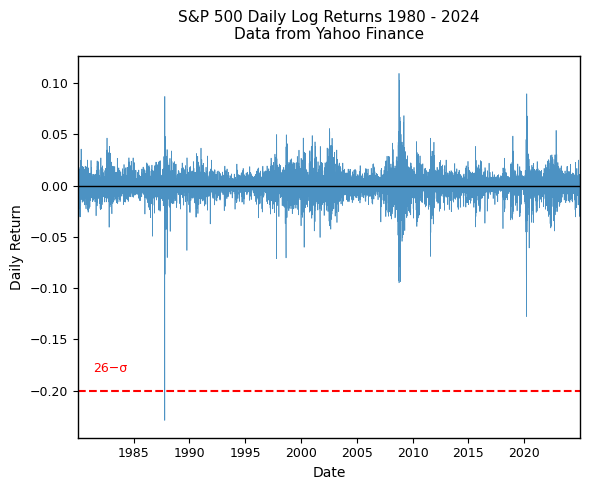

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Figure 1.2 — S&P 500 daily log-returns
# This notebook downloads S&P 500 prices, computes daily log-returns
# and exports the figure used in Chapter 1 of the thesis

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2024-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Remove missing observations
df = df.dropna()

# Compute daily logarithmic returns
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

# Identify the most negative return used conceptually as the extreme event
event_date = df["Log_Returns"].idxmin()

# Figure construction
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    df.index,
    df["Log_Returns"],
    linewidth=0.5,
    color="#1f77b4",
    alpha=0.8
)

ax.axhline(y=0, color="black", linewidth=1)
ax.axhline(y=-0.20, color="red", linestyle="--", linewidth=1.5)

ax.text(
    df.index.min() + pd.Timedelta(days=500),
    -0.20 + 0.015,
    "26−σ",
    color="red",
    fontsize=9,
    verticalalignment="bottom",
    horizontalalignment="left"
)

# Axis formatting and title
ax.set_title(
    "S&P 500 Daily Log Returns 1980 - 2024\nData from Yahoo Finance",
    pad=12
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.set_xlim(df.index.min(), df.index.max())

for spine in ax.spines.values():
    spine.set_linewidth(1)

ax.grid(False)

if ax.get_legend():
    ax.get_legend().remove()

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_1_2_returns.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()